Задача "Леденцы".

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [14]:
df = pd.read_csv('Леденцы.dat', sep=';')

V1: Я потребляю леденцы, чтобы освежить дыхание

V2: Я потребляю леденцы, чтобы чувствовать себя увереннее

V3: Я потребляю леденцы, чтобы освежить полость рта

V4: Я потребляю леденцы, чтобы избавиться от неприятного вкуса во рту

V5: Я потребляю леденцы как заменитель других кондитерских изделий

V6: Я потребляю леденцы, когда мне хочется чего-нибудь сладкого

V7: Леденцы помогают мне сконцентрироваться

V8: Я потребляю леденцы, чтобы отвлечься на несколько минут и подумать

V9: Я потребляю леденцы для того, чтобы облегчить боль в горле

V10: Я потребляю леденцы для того, чтобы избавиться от заложенности носа

V11: Я потребляю леденцы для улучшения самочувствия


Кластеры:
1. люди, употребляющие леденцы в качестве сладости (вопросы 5, 6)
2. люди, употребляющие леденцы для лечения (вопросы 9, 10, 11)
3. люди, употребляющие леденцы для освежения дыхания (вопросы 1, 3, 4)
4. люди, употребляющие леденцы по ментальным причинам (вопросы 2, 7, 8)

In [49]:
model = AgglomerativeClustering(
    n_clusters=8, linkage="ward"
)
df['cluster'] = model.fit_predict(df)
print(silhouette_score(df.drop(['cluster'], axis=1), model.labels_))

0.7439068610184306


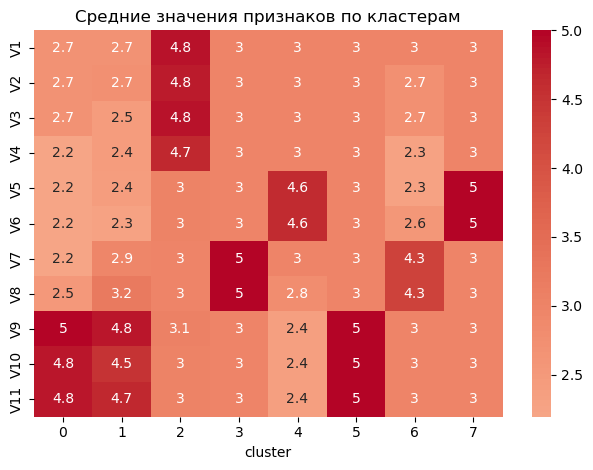

In [39]:
cluster_means = df.groupby('cluster').mean()
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', center=0)
plt.title('Средние значения признаков по кластерам')
plt.tight_layout()
plt.show()

В целом, наше предположение об интерпретации кластеров подтверждается, только высокие значения признака V2 больше характерны не для кластера 4, а для кластера 3.

Построим график зависимости silhouette_score от числа кластеров:

100%|██████████| 9/9 [00:00<00:00, 133.06it/s]


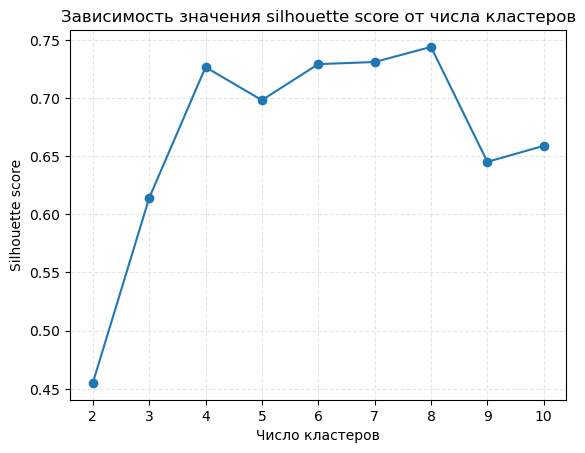

In [42]:
n_clusters = [i for i in range(2, 11)]
scores = []

for i in tqdm(n_clusters):
    model = AgglomerativeClustering(n_clusters=i, linkage='ward')
    if 'cluster' in df.columns:
        df['cluster'] = model.fit(df.drop(['cluster'], axis=1))
    else:
        df['cluster'] = model.fit(df)
    scores.append(silhouette_score(df.drop(['cluster'], axis=1), model.labels_))

plt.plot(n_clusters, scores, marker='o')
plt.title('Зависимость значения silhouette score от числа кластеров')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette score')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Дендрограмма:

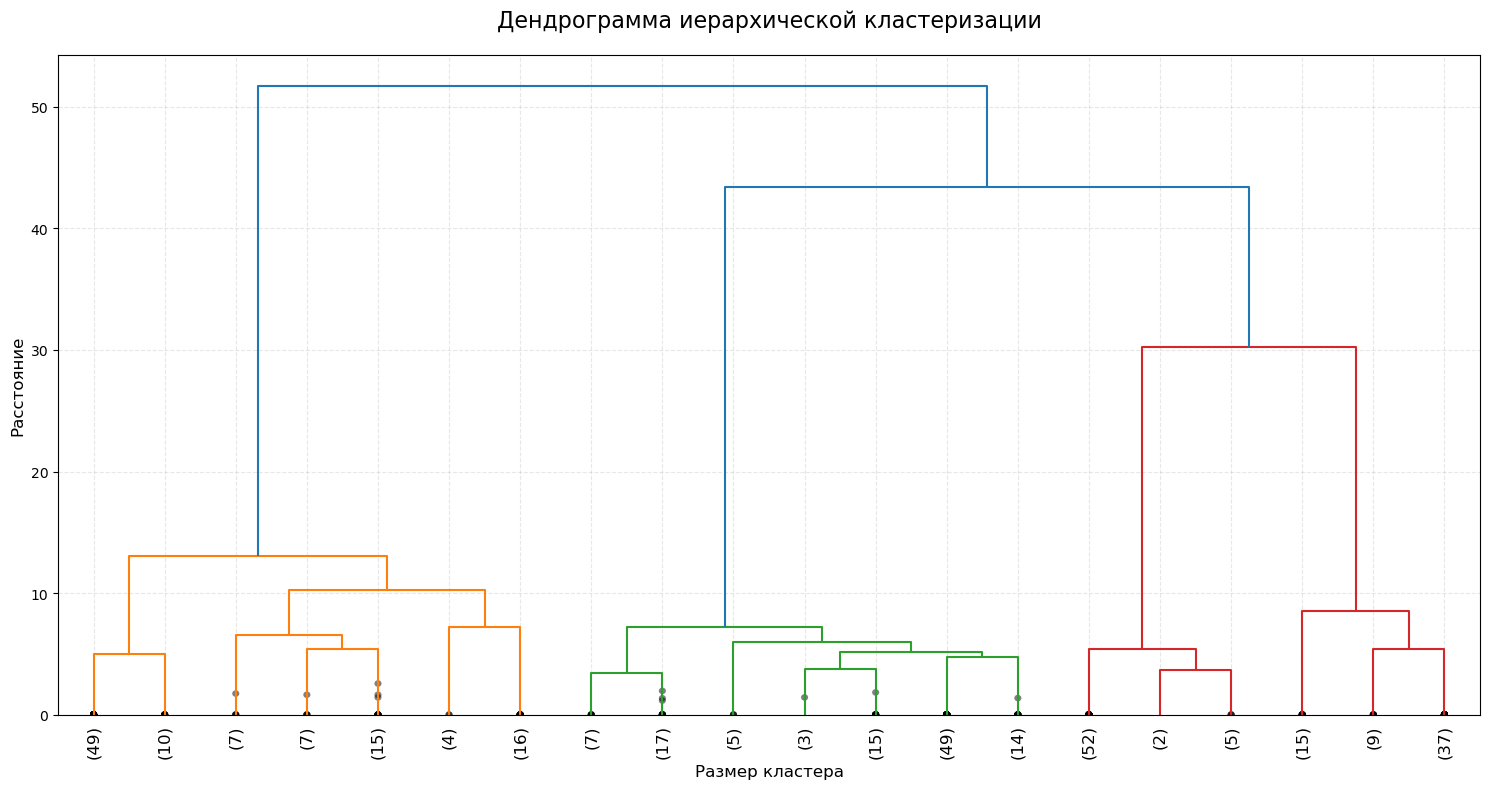

In [18]:
plt.figure(figsize=(15, 8))

Z = linkage(df, method='ward', metric='euclidean')

dendrogram(Z,
           truncate_mode='lastp',
           p=20, 
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=12,
           show_contracted=True)

plt.title('Дендрограмма иерархической кластеризации', fontsize=16, pad=20)
plt.xlabel('Размер кластера', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

100%|██████████| 9/9 [00:00<00:00, 134.31it/s]


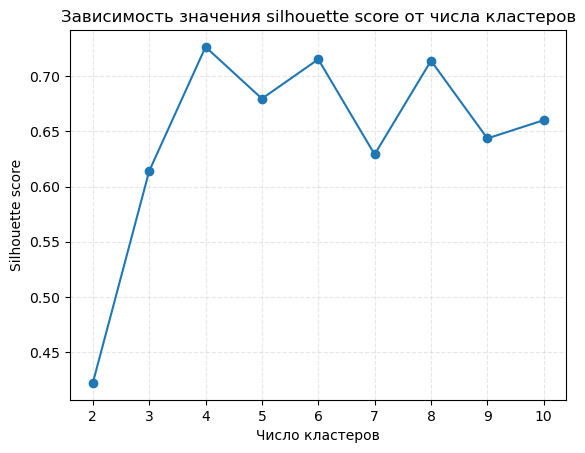

In [44]:
n_clusters = [i for i in range(2, 11)]
scores = []

for i in tqdm(n_clusters):
    model = KMeans(n_clusters=i)
    if 'cluster' in df.columns:
        df['cluster'] = model.fit(df.drop(['cluster'], axis=1))
    else:
        df['cluster'] = model.fit(df)
    scores.append(silhouette_score(df.drop(['cluster'], axis=1), model.labels_))

plt.plot(n_clusters, scores, marker='o')
plt.title('Зависимость значения silhouette score от числа кластеров')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette score')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [47]:
model = KMeans(
    n_clusters=4
)
df['cluster'] = model.fit_predict(df.drop(['cluster'], axis=1))
print(silhouette_score(df.drop(['cluster'], axis=1), model.labels_))

0.7265095702205504


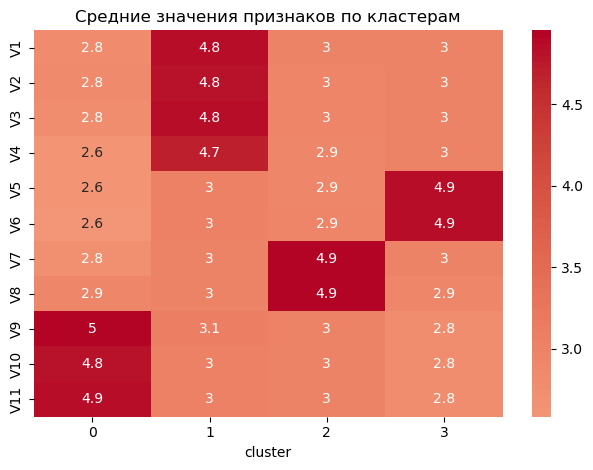

In [48]:
cluster_means = df.groupby('cluster').mean()
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', center=0)
plt.title('Средние значения признаков по кластерам')
plt.tight_layout()
plt.show()

In [34]:
epsilons = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5]
min_samples = [5, 10, 15, 20, 25]
n_clusters = []
scores = []
best_epsilon = 0
best_min_samples = 0
best_score = 0
best_n_clusters = 0
for n_samples in min_samples:
    for eps in epsilons:
        model = DBSCAN(eps=eps, min_samples=n_samples)
        if 'cluster' in df.columns:
            df['cluster'] = model.fit_predict(df.drop(['cluster'], axis=1))
        else:
            df['cluster'] = model.fit_predict(df)
        # n_clusters.append(df['cluster'].unique().shape[0])
        # scores.append(silhouette_score(df.drop(['cluster'], axis=1), model.labels_))
        score = silhouette_score(df.drop(['cluster'], axis=1), model.labels_)
        if score > best_score:
            best_score = score
            best_epsilon = eps
            best_n_clusters = df['cluster'].unique().shape[0]
            best_min_samples = n_samples

print(f'Best silhouette score = {best_score}')
print(f'Best eps = {best_epsilon}')
print(f'Best min_samples = {best_min_samples}')
print(f'Best n_clusters = {best_n_clusters}')

Best silhouette score = 0.7219734013050195
Best eps = 1.0
Best min_samples = 5
Best n_clusters = 10


In [36]:
model = DBSCAN(eps=1.0, min_samples=5)
df['cluster'] = model.fit_predict(df)
print(silhouette_score(df.drop(['cluster'], axis=1), model.labels_))

0.7219734013050195


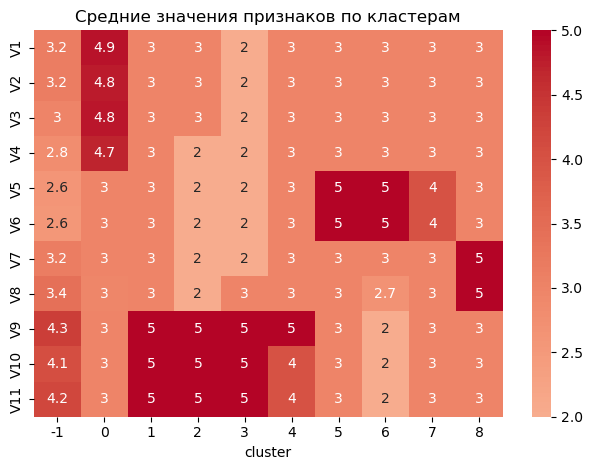

In [37]:
cluster_means = df.groupby('cluster').mean()
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', center=0)
plt.title('Средние значения признаков по кластерам')
plt.tight_layout()
plt.show()

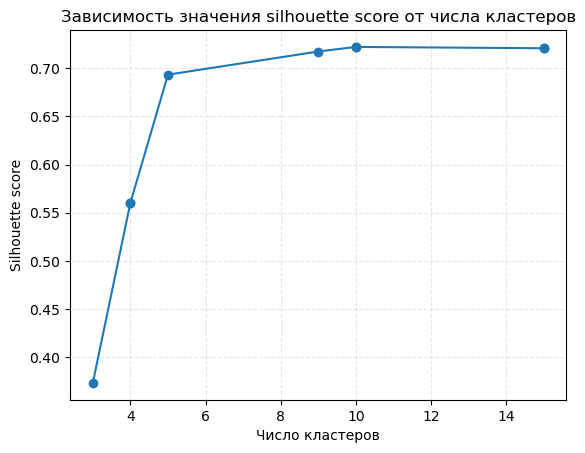

In [23]:
plt.plot(n_clusters, scores, marker='o')
plt.title('Зависимость значения silhouette score от числа кластеров')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette score')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()